## **Cleaning Data in Python live training**


Welcome to this live, hands-on training where you will learn how to effectively diagnose and treat missing data in Python.

The majority of data science work often revolves around pre-processing data, and making sure it's ready for analysis. In this session, we will be covering how transform our raw data into accurate insights. In this notebook, you will learn:

* Import data into `pandas`, and use simple functions to diagnose problems in our data.
* Visualize missing and out of range data using `missingno` and `seaborn`.
* Apply a range of data cleaning tasks that will ensure the delivery of accurate insights.

## **The Dataset**

The dataset to be used in this webinar is a CSV file named `airbnb.csv`, which contains data on airbnb listings in the state of New York. It contains the following columns:

- `listing_id`: The unique identifier for a listing
- `description`: The description used on the listing
- `host_id`: Unique identifier for a host
- `host_name`: Name of host
- `neighbourhood_full`: Name of boroughs and neighbourhoods
- `coordinates`: Coordinates of listing _(latitude, longitude)_
- `Listing added`: Date of added listing
- `room_type`: Type of room
- `rating`: Rating from 0 to 5.
- `price`: Price per night for listing
- `number_of_reviews`: Amount of reviews received
- `last_review`: Date of last review
- `reviews_per_month`: Number of reviews per month
- `availability_365`: Number of days available per year
- `Number of stays`: Total number of stays thus far


## **Getting started**

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import missingno as msno
import datetime as dt

In [2]:
# Read in the dataset
airbnb = pd.read_csv('https://raw.githubusercontent.com/kflisikowsky/Descriptive_Statistics/refs/heads/main/data/airbnb.csv', index_col = 'Unnamed: 0')

## **Diagnosing data cleaning problems using simple `pandas` and visualizations**

Some important and common methods needed to get a better understanding of DataFrames and diagnose potential data problems are the following:

- `.head()` prints the header of a DataFrame
- `.dtypes` prints datatypes of all columns in a DataFrame
- `.info()` provides a bird's eye view of column data types and missing values in a DataFrame
- `.describe()` returns a distribution of numeric columns in your DataFrame
- `.isna().sum()` allows us to break down the number of missing values per column in our DataFrame
- `.unique()` finds the number of unique values in a DataFrame column

<br>

- `sns.histplot()` plots the distribution of one column in your DataFrame.

In [3]:
# Print the header of the DataFrame
airbnb.head()

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands","(40.63222, -73.93398)",Private room,45$,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side","(40.78761, -73.96862)",Entire home/apt,135$,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights","(40.7007, -73.99517)",Entire home/apt,150$,0,NaN,NaN,65,NaN,NaN,NaN,2018-08-15
3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side","(40.79169, -73.97498)",Entire home/apt,86$,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side","(40.71884, -73.98354)",Private room,160$,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23


Printing the data types confirms that `coordinates` and `price` need to be converted to `float`, and date columns need to be converted to `datetime` _(**problems 1,2 3)**_

In [4]:
# Print info of DataFrame
airbnb.info()

<class 'pandas.DataFrame'>
RangeIndex: 10019 entries, 0 to 10018
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   listing_id          10019 non-null  int64  
 1   name                10014 non-null  str    
 2   host_id             10019 non-null  int64  
 3   host_name           10017 non-null  str    
 4   neighbourhood_full  10019 non-null  str    
 5   coordinates         10019 non-null  str    
 6   room_type           10019 non-null  str    
 7   price               9781 non-null   str    
 8   number_of_reviews   10019 non-null  int64  
 9   last_review         7944 non-null   str    
 10  reviews_per_month   7944 non-null   float64
 11  availability_365    10019 non-null  int64  
 12  rating              7944 non-null   float64
 13  number_of_stays     7944 non-null   float64
 14  5_stars             7944 non-null   float64
 15  listing_added       10019 non-null  str    
dtypes: float64(4), 

Printing the info confirms our hunch about the following:

- There is missing data in the `price`, `last_review`, `reviews_per_month`, `rating`, `number_of_stays`, `5_stars` columns. It also seems that the missingness of `last_review`, `reviews_per_month`, `rating`, `number_of_stays`, `5_stars` are related since they have the same amount of missing data. We will confirm later with `missingno` _(**problem 4**)_.

In [5]:
# Print number of missing values
airbnb.isna().sum()

listing_id               0
name                     5
host_id                  0
host_name                2
neighbourhood_full       0
coordinates              0
room_type                0
price                  238
number_of_reviews        0
last_review           2075
reviews_per_month     2075
availability_365         0
rating                2075
number_of_stays       2075
5_stars               2075
listing_added            0
dtype: int64

There are a variety of ways of dealing with missing data that is dependent on type of missingness, as well as the business assumptions behind our data - our options could be:

- Dropping missing data (if the data dropped does not impact or skew our data)
- Setting to missing and impute with statistical measures (median, mean, mode ...)
- Imputing with more complex algorithmic/machine learning based approaches
- Impute based on business assumptions of our data

In [6]:
# Print description of DataFrame
airbnb.describe()

,listing_id,host_id,number_of_reviews,reviews_per_month,availability_365,rating,number_of_stays,5_stars
count,1.001900e+04,1.001900e+04,10019.000000,7944.000000,10019.000000,7944.000000,7944.000000,7944.000000
mean,1.927634e+07,6.795923e+07,22.459727,1.353894,112.284260,4.014458,33.991541,0.718599
std,1.095056e+07,7.863106e+07,43.173896,1.615380,131.636043,0.575064,56.089279,0.079978
min,3.831000e+03,2.787000e+03,0.000000,0.010000,0.000000,3.000633,1.200000,0.600026
25%,9.674772e+06,7.910880e+06,1.000000,0.200000,0.000000,3.520443,3.600000,0.655576
50%,2.007030e+07,3.165167e+07,5.000000,0.710000,44.000000,4.027965,10.800000,0.709768
75%,2.933864e+07,1.074344e+08,22.000000,2.000000,226.000000,4.516378,38.400000,0.763978
max,3.648724e+07,2.741034e+08,510.000000,16.220000,365.000000,5.181114,612.000000,0.950339




- **Problem 7:** Looking at the maximum of the `rating` column - we see that it is out of range of `5` which is the maximum rating possible. We need to make sure we fix the range this column.

It's worth noting that `.describe()` does not offer a bird's eye view of all the out of range data we have, for example, what if we have date data in the future? Or given our dataset, `listing_added` dates that are in the future of `last_review` dates?

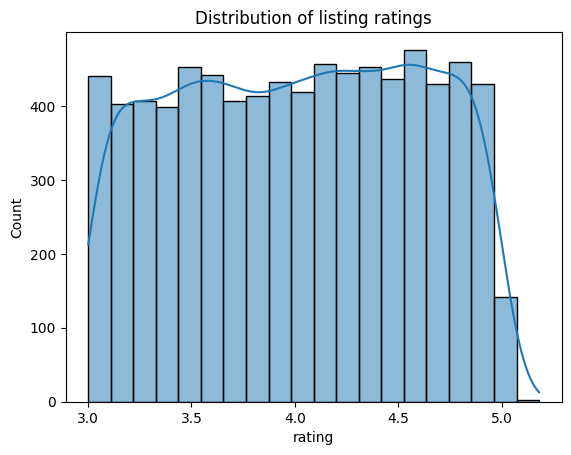

In [7]:
# Visualize the distribution of the rating column
sns.histplot(airbnb['rating'], kde=True, bins = 20)
plt.title('Distribution of listing ratings')
plt.show()

In [8]:
# Find number of unique values in room_type column
airbnb['room_type'].unique()

<StringArray>
[        'Private room',      'Entire home/apt',              'Private',
          'Shared room',         'PRIVATE ROOM',                 'home',
 '   Shared room      ']
Length: 7, dtype: str

- **Problem 8**: There are trailing spaces and capitalization issues with `room_type`, we need to fix this problem.

In [9]:
# How many values of different room_types do we have?
airbnb['room_type'].value_counts()

room_type
Entire home/apt         5120
Private room            4487
Shared room              155
Private                   89
   Shared room            71
home                      66
PRIVATE ROOM              31
Name: count, dtype: int64

In [10]:
airbnb['price'].head(5)

0     45$
1    135$
2    150$
3     86$
4    160$
Name: price, dtype: str

## **Our to do list:**

_Data type problems:_

- **Task 1**: Split `coordinates` into 2 columns and convert them to `float`
- **Task 2**: Remove `$` from `price` and convert it to `float`
- **Task 3**: Convert `listing_added` and `last_review` to `datetime`

<br>

_Text/categorical data problems:_

- **Task 4**: We need to collapse `room_type` into correct categories
- **Task 5**: Divide `neighbourhood_full` into 2 columns and making sure they are clean

<br>

_Data range problems:_

- **Task 6**: Make sure we set the correct maximum for `rating` column out of range values

<br>

_Dealing with missing data:_

- **Task 7**: Understand the type of missingness, and deal with the missing data in most of the remaining columns.

<br>

_Is that all though?_

- We need to investigate if we duplicates in our data
- We need to make sure that data makes sense by applying some sanity checks on our DataFrame

## **Q&A**

## **Cleaning data**

### Data type problems

In [11]:
# Reminder of the DataFrame
airbnb.head()

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands","(40.63222, -73.93398)",Private room,45$,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side","(40.78761, -73.96862)",Entire home/apt,135$,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights","(40.7007, -73.99517)",Entire home/apt,150$,0,NaN,NaN,65,NaN,NaN,NaN,2018-08-15
3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side","(40.79169, -73.97498)",Entire home/apt,86$,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side","(40.71884, -73.98354)",Private room,160$,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23


##### **Task 1:** Replace `coordinates` with `latitude` and `longitude` columns

To perform this task, we will use the following methods:

- `.str.replace("","")` replaces one string in each row of a column with another
- `.str.split("")` takes in a string and lets you split a column into two based on that string
- `.astype()` lets you convert a column from one type to another

In [12]:
#removing ()
airbnb['coordinates'] = airbnb['coordinates'].str.replace('(', '').str.replace(')', '').str.replace(' ', '')

#splitting into 2 columns
airbnb[['latitude', 'longitude']] = airbnb['coordinates'].str.split(',', expand=True)

# convert to float
airbnb['latitude'] = airbnb['latitude'].astype(float)
airbnb['longitude'] = airbnb['longitude'].astype(float)


##### **Task 2:** Remove `$` from `price` and convert it to `float`

To perform this task, we will be using the following methods:

- `.str.strip()` which removes a specified string from each row in a column
- `.astype()`

In [13]:
# Calculate mean of price without conversion
airbnb['price'].mean()

TypeError: Cannot perform reduction 'mean' with string dtype

In [ ]:
# Remove $ from price before conversion to float
airbnb['price'] = airbnb['price'].str.strip("$")
# Print header to make sure change was done
airbnb['price'].head()

0     45
1    135
2    150
3     86
4    160
Name: price, dtype: str

In [ ]:
# Convert price to float
airbnb['price'] = airbnb['price'].astype('float')
# Calculate mean of price after conversion
avg = airbnb['price'].mean()
airbnb['price'] = airbnb['price'].fillna(avg)

##### **Task 3:** Convert `listing_added` and `last_review` columns to `datetime`

To perform this task, we will use the following functions:

- `pd.to_datetime(format = "")`
  - `format` takes in the desired date format `"%Y-%m-%d"`

In [ ]:
# Print header of two columns
airbnb[['listing_added', 'last_review']].head()

,listing_added,last_review
0,2018-06-08,2018-12-12
1,2018-12-25,2019-06-30
2,2018-08-15,NaN
3,2017-03-20,2017-09-23
4,2020-10-23,2019-06-12


In [ ]:
airbnb['listing_added'] = pd.to_datetime(airbnb['listing_added'], format='%Y-%m-%d')
airbnb['last_review'] = pd.to_datetime(airbnb['last_review'], format='%Y-%m-%d')

airbnb[['listing_added', 'last_review']].dtypes

listing_added    datetime64[us]
last_review      datetime64[us]
dtype: object

### Text and categorical data problems

##### **Task 4:** We need to collapse `room_type` into correct categories

To perform this task, we will be using the following methods:

- `.str.lower()` to lowercase all rows in a string column
- `.str.strip()` to remove all white spaces of each row in a string column
- `.replace()` to replace values in a column with another

In [ ]:
# Print unique values of `room_type`
airbnb['room_type'].unique()

<StringArray>
[        'Private room',      'Entire home/apt',              'Private',
          'Shared room',         'PRIVATE ROOM',                 'home',
 '   Shared room      ']
Length: 7, dtype: str

In [ ]:
# Deal with capitalized values
airbnb['room_type'] = airbnb['room_type'].str.lower()
airbnb['room_type'].unique()

<StringArray>
[        'private room',      'entire home/apt',              'private',
          'shared room',                 'home', '   shared room      ']
Length: 6, dtype: str

In [ ]:
# Deal with trailing spaces
airbnb['room_type'] = airbnb['room_type'].str.strip()
airbnb['room_type'].unique()

<StringArray>
['private room', 'entire home/apt', 'private', 'shared room', 'home']
Length: 5, dtype: str

In [ ]:
# Replace values to 'Shared room', 'Entire place', 'Private room' and 'Hotel room' (if applicable).
mappings = {'private room': 'Private Room',
            'private': 'Private Room',
            'entire home/apt': 'Entire place',
            'shared room': 'Shared room',
            'home': 'Entire place'}

# Replace values and collapse data
airbnb['room_type'] = airbnb['room_type'].replace(mappings)
airbnb['room_type'].unique()

<StringArray>
['Private Room', 'Entire place', 'Shared room']
Length: 3, dtype: str

##### **Task 5:** Divide `neighbourhood_full` into 2 columns and making sure they are clean

In [ ]:
# Print header of column
airbnb['neighbourhood_full'].head()

0           Brooklyn, Flatlands
1    Manhattan, Upper West Side
2    Brooklyn, Brooklyn Heights
3    Manhattan, Upper West Side
4    Manhattan, Lower East Side
Name: neighbourhood_full, dtype: str

In [ ]:
#splitting
airbnb[['borough', 'neighbourhood']] = airbnb['neighbourhood_full'].str.split(',', expand=True)

In [ ]:
#space removing
airbnb['borough'] = airbnb['borough'].str.strip()
airbnb['neighbourhood'] = airbnb['neighbourhood'].str.strip()

airbnb[['borough', 'neighbourhood']].head()

,borough,neighbourhood
0,Brooklyn,Flatlands
1,Manhattan,Upper West Side
2,Brooklyn,Brooklyn Heights
3,Manhattan,Upper West Side
4,Manhattan,Lower East Side


##### **Task 6:** Make sure we set the correct maximum for `rating` column out of range values

In [ ]:
airbnb['rating'] = airbnb['rating'].clip(upper=5)

airbnb['rating'].max()

np.float64(5.0)

## **Q&A**

### Dealing with missing data

The `missingno` (imported as `msno`) package is great for visualizing missing data - we will be using:

- `msno.matrix()` visualizes a missingness matrix
- `msno.bar()` visualizes a missngness barplot
- `msno.dendrogram()` visualizes all connections (clusters) between NA's
- `plt.show()` to show the plot

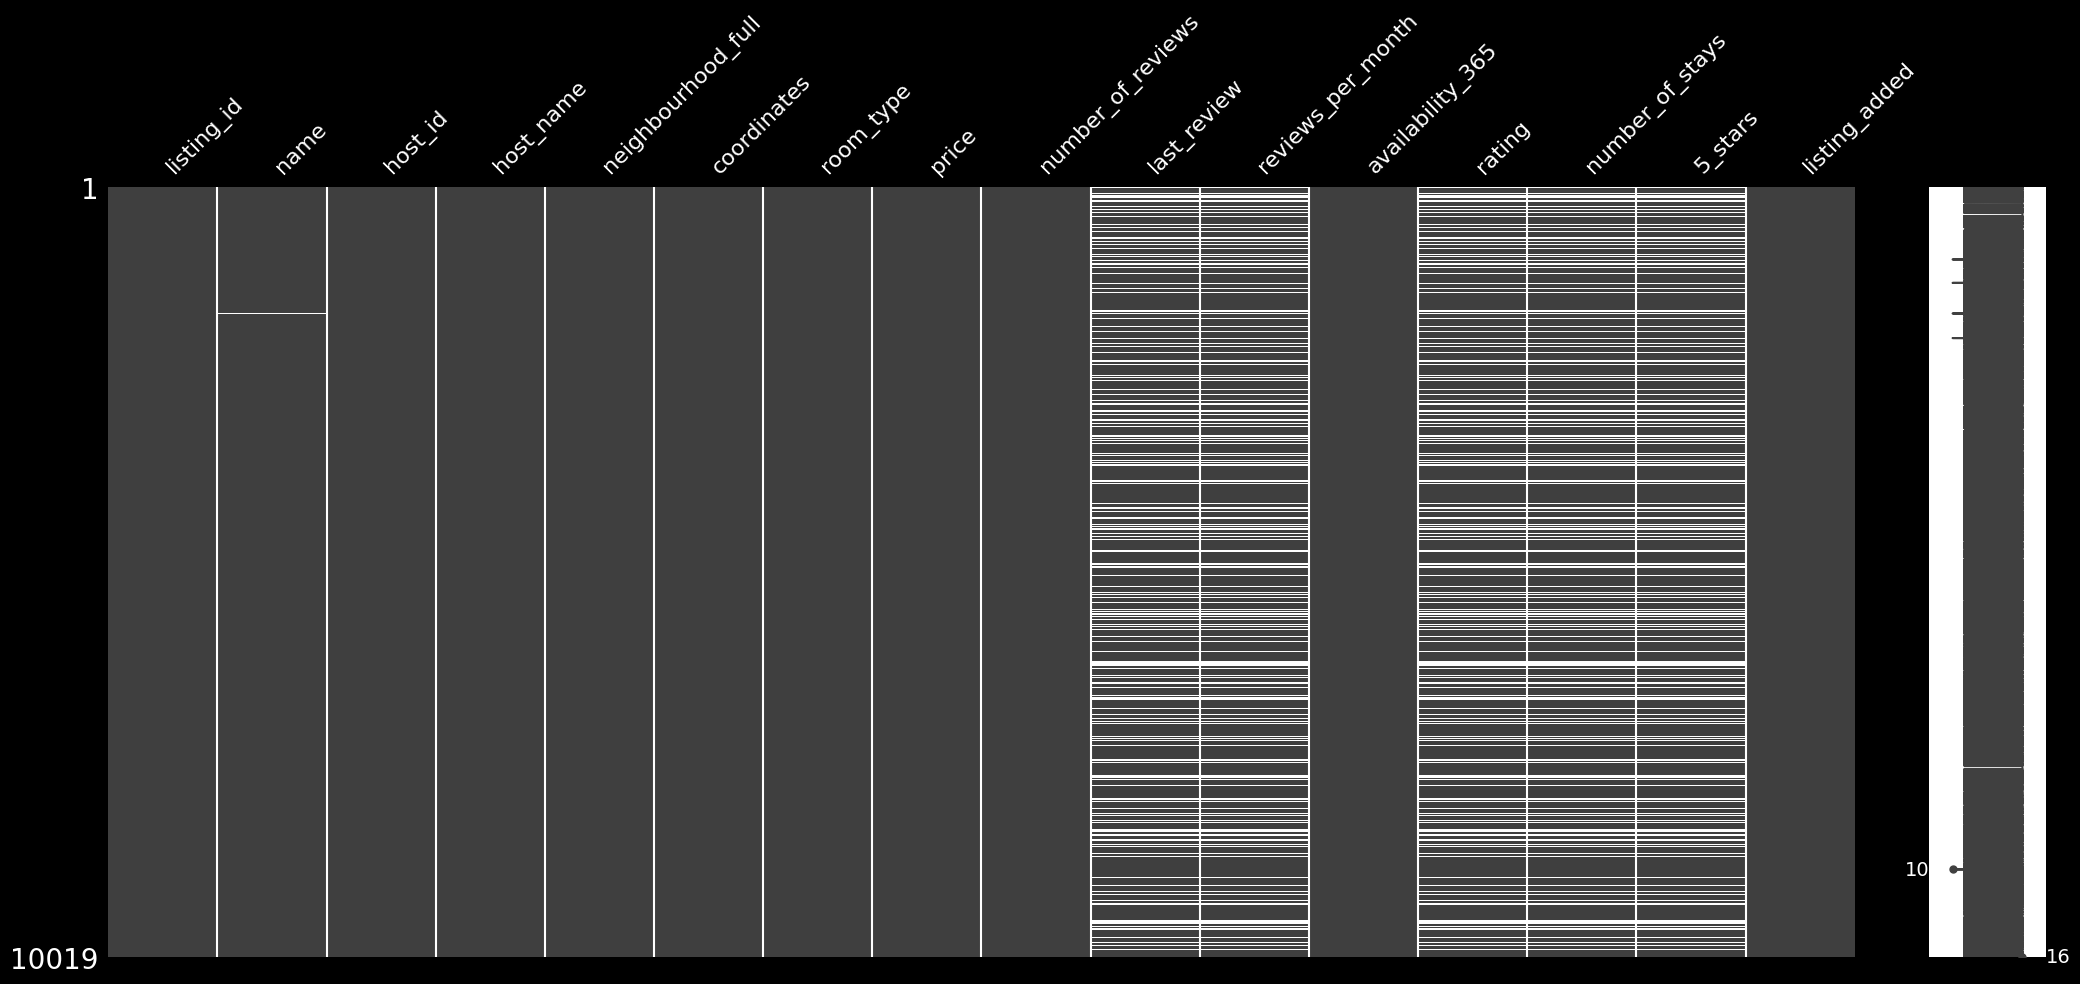

In [ ]:
# Visualize the missingness
msno.matrix(airbnb)
plt.show()

Looking at the missingness matrix, we can see that missing values are almost identical between `last_review`, `reviews_per_month`, `rating`, `number_of_stays`, and `5_stars`. Let's confirm this further by sorting on `rating`.

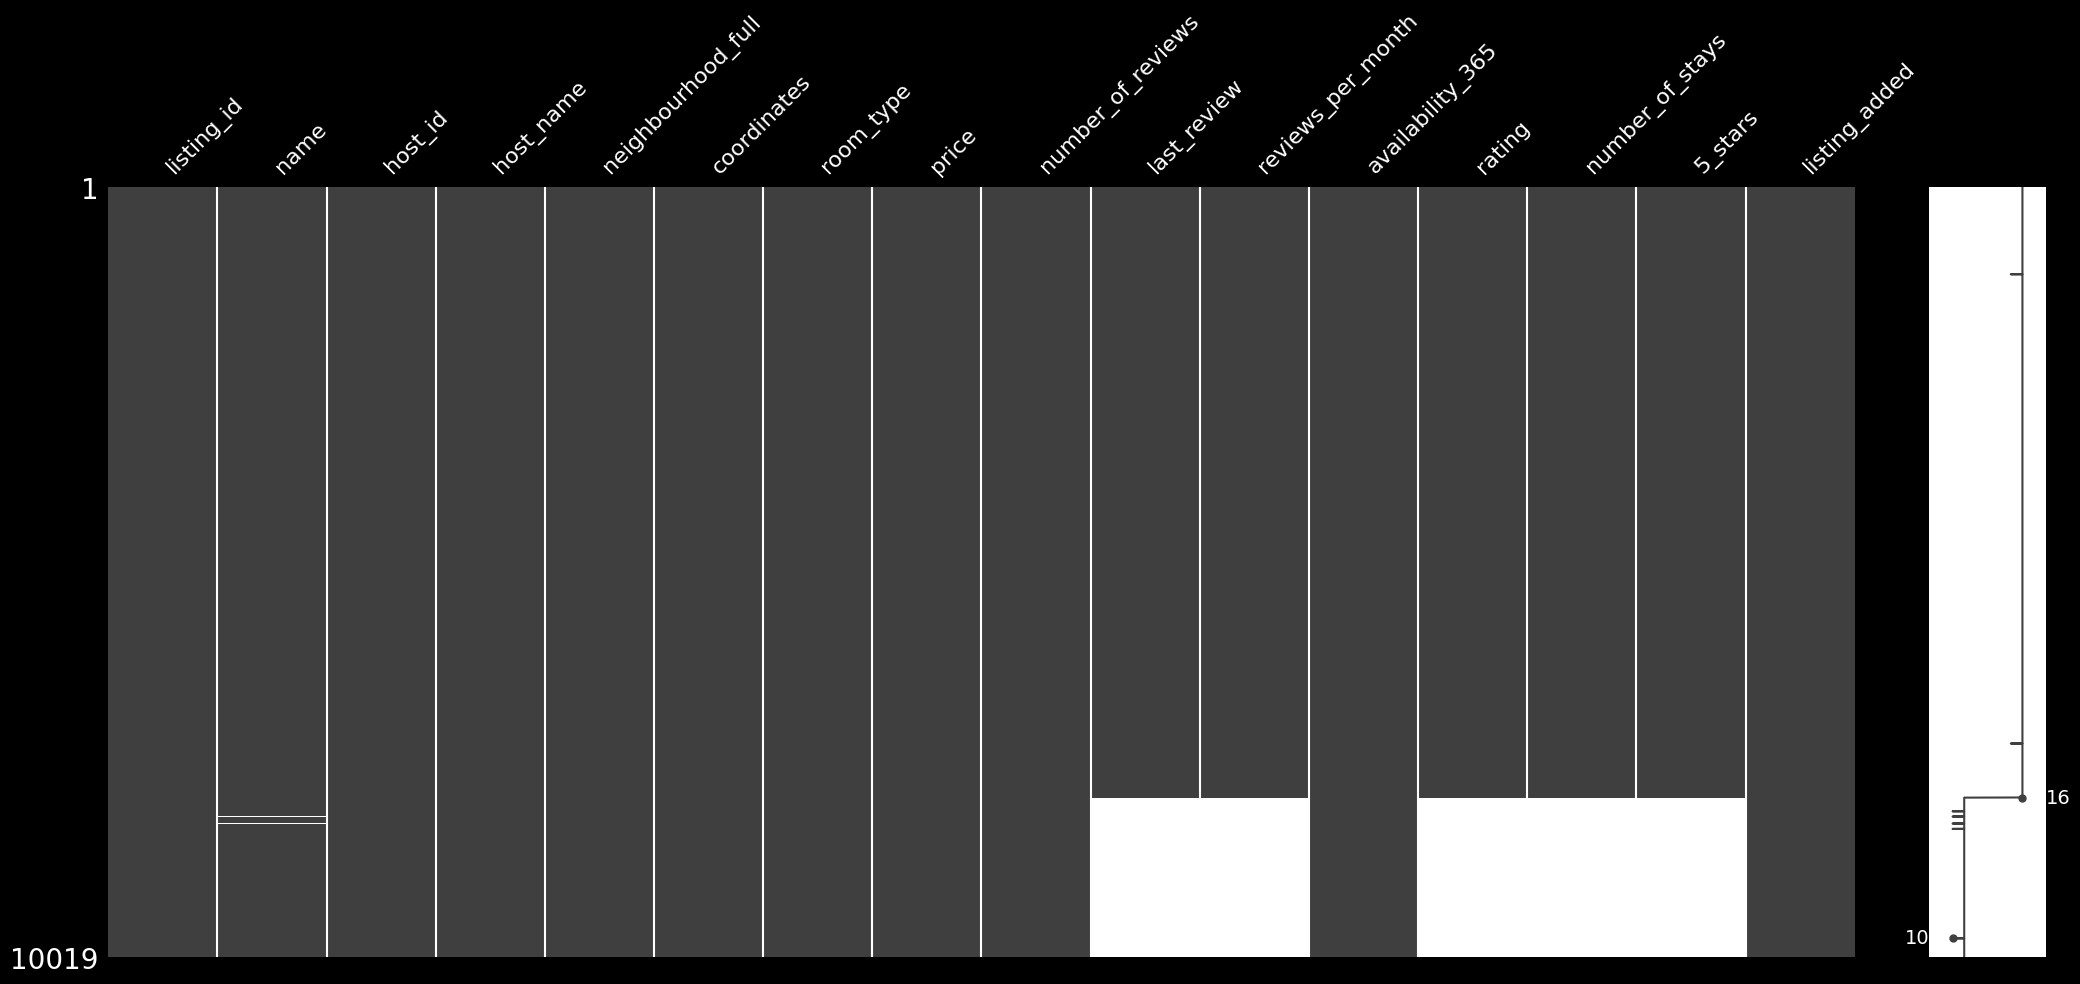

In [ ]:
# Visualize the missingness on sorted values
msno.matrix(airbnb.sort_values(by = 'rating'))
plt.show()

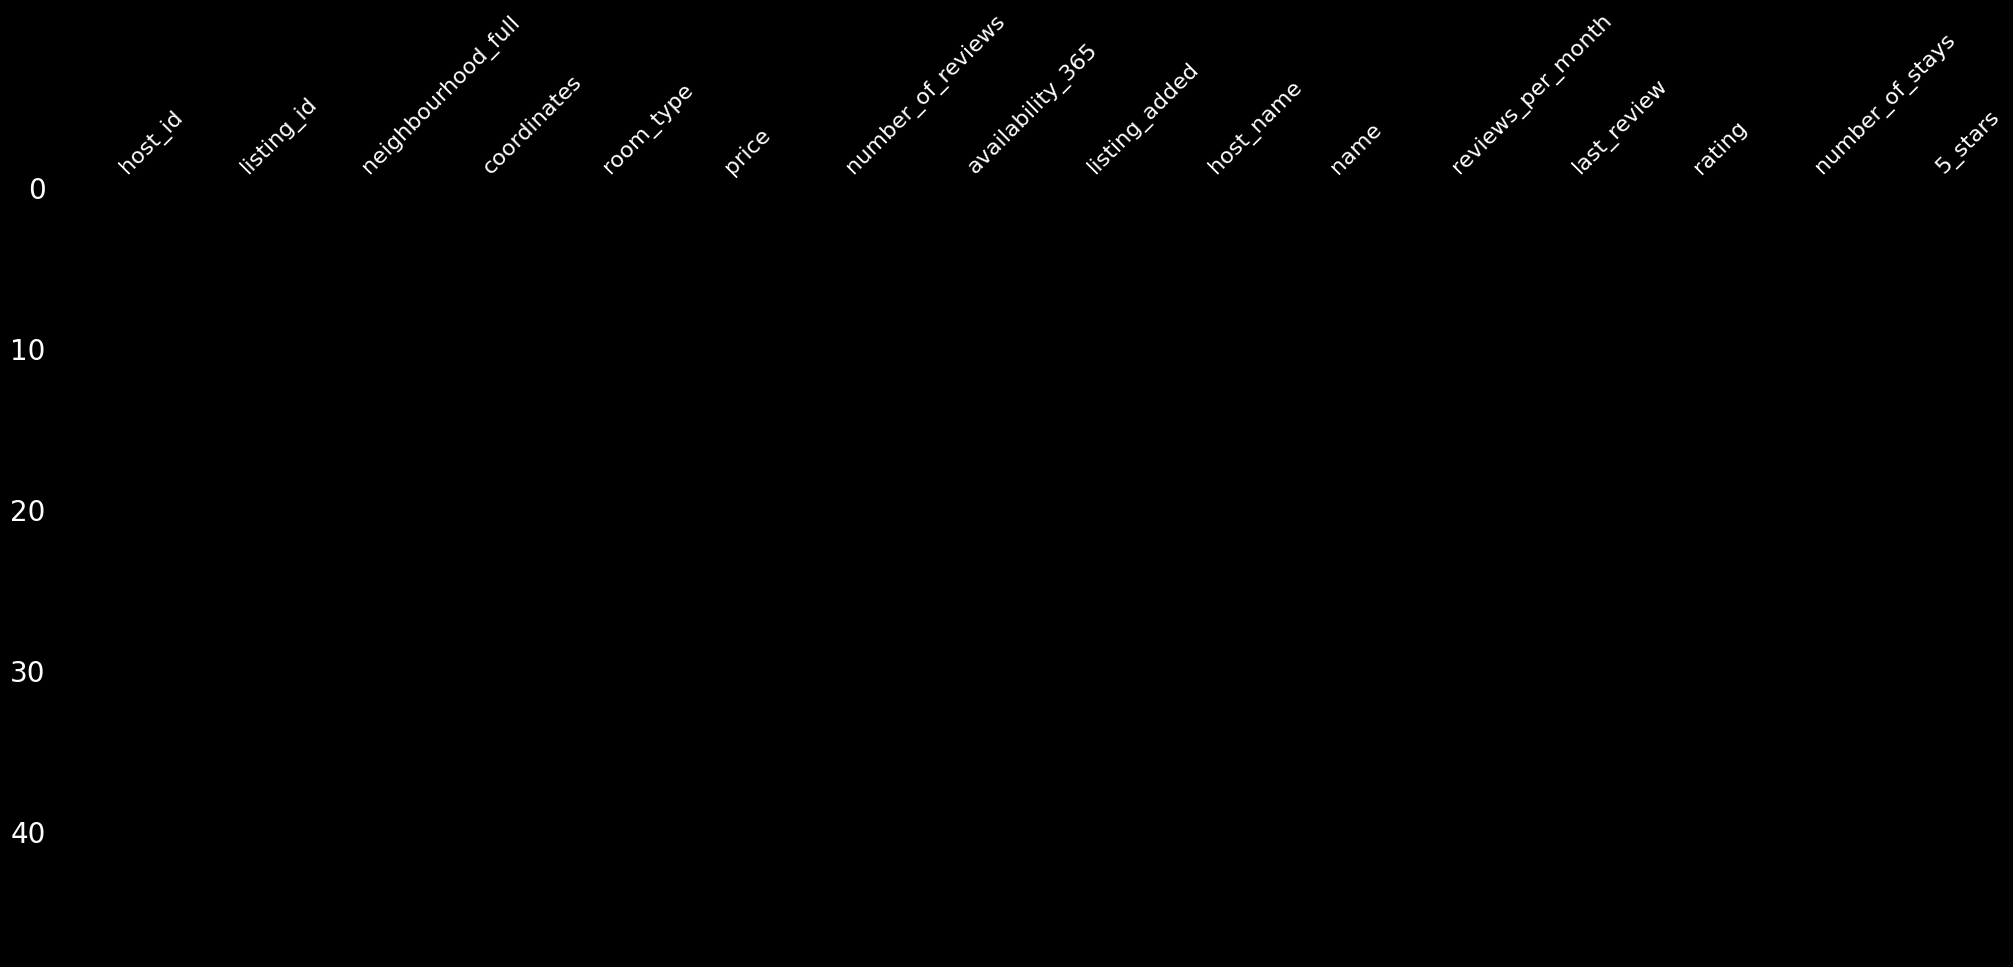

In [ ]:
msno.dendrogram(airbnb)
plt.show()

<Axes: >

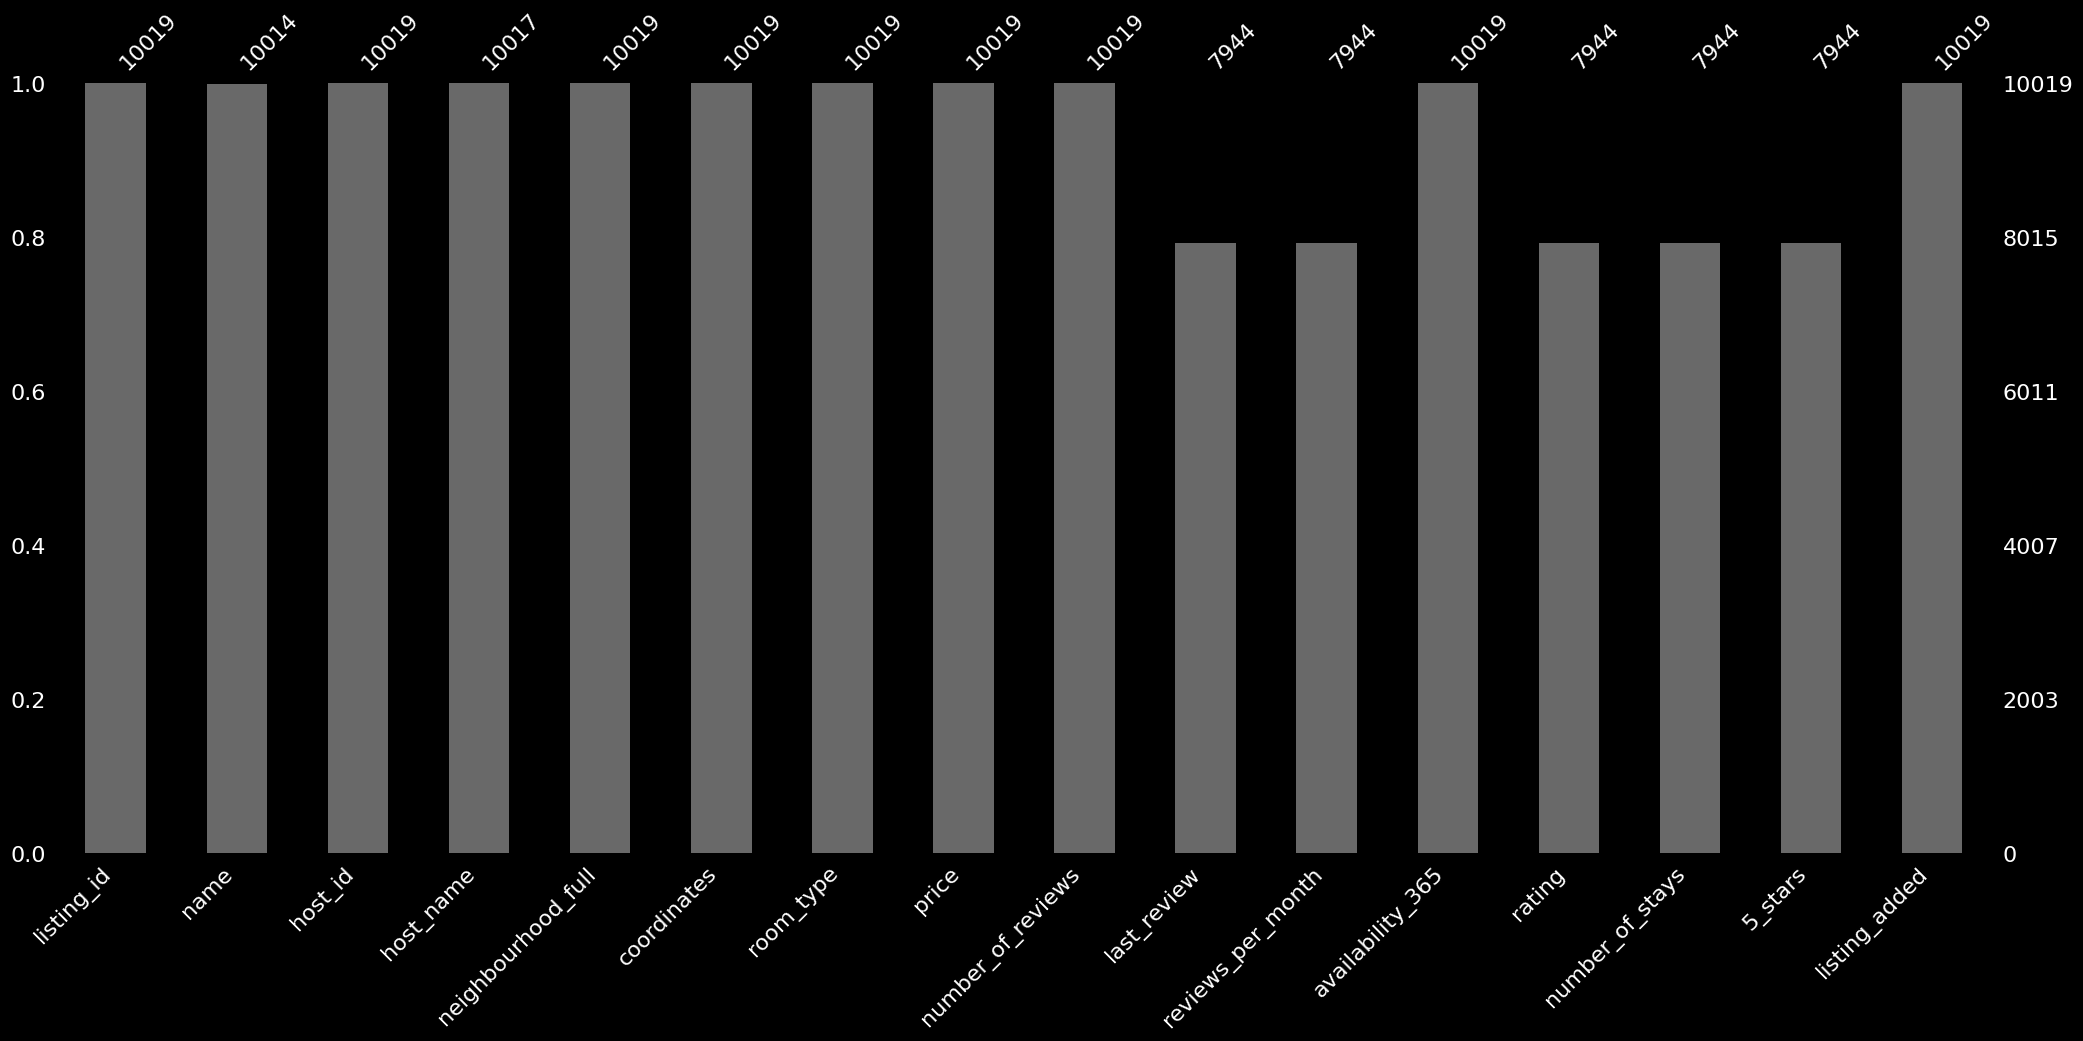

In [ ]:
# Missingness barplot
msno.bar(airbnb)

**Treating the** `rating`, `number_of_stays`, `5_stars`, `reviews_per_month` **columns**

In [ ]:
# Understand DataFrame with missing values in rating, number_of_stays, 5_stars, reviews_per_month
airbnb[airbnb['rating'].isna()].describe()

,listing_id,host_id,price,number_of_reviews,reviews_per_month,availability_365,rating,number_of_stays,5_stars
count,2.075000e+03,2.075000e+03,2075.000000,2075.0,0.0,2075.000000,0.0,0.0,0.0
mean,2.274238e+07,8.022455e+07,190.633032,0.0,NaN,104.531566,NaN,NaN,NaN
std,1.123730e+07,8.663163e+07,312.642005,0.0,NaN,138.266525,NaN,NaN,NaN
min,6.358800e+04,1.475100e+04,0.000000,0.0,NaN,0.000000,NaN,NaN,NaN
25%,1.232923e+07,1.224305e+07,70.000000,0.0,NaN,0.000000,NaN,NaN,NaN
50%,2.345182e+07,4.040116e+07,120.000000,0.0,NaN,7.000000,NaN,NaN,NaN
75%,3.400364e+07,1.333498e+08,200.000000,0.0,NaN,211.000000,NaN,NaN,NaN
max,3.648724e+07,2.741034e+08,5250.000000,0.0,NaN,365.000000,NaN,NaN,NaN


In [ ]:
# Understand DataFrame with missing values in rating, number_of_stays, 5_stars, reviews_per_month
airbnb[~airbnb['rating'].isna()].describe()

,listing_id,host_id,price,number_of_reviews,reviews_per_month,availability_365,rating,number_of_stays,5_stars
count,7.944000e+03,7.944000e+03,7944.000000,7944.000000,7944.000000,7944.000000,7944.000000,7944.000000,7944.000000
mean,1.837100e+07,6.475548e+07,140.528056,28.326284,1.353894,114.309290,4.014458,33.991541,0.718599
std,1.069161e+07,7.608428e+07,161.696882,46.741066,1.615380,129.781153,0.575064,56.089279,0.079978
min,3.831000e+03,2.787000e+03,0.000000,1.000000,0.010000,0.000000,3.000633,1.200000,0.600026
25%,8.970241e+06,7.137797e+06,69.000000,3.000000,0.200000,0.000000,3.520443,3.600000,0.655576
50%,1.928118e+07,2.949374e+07,109.000000,9.000000,0.710000,54.000000,4.027965,10.800000,0.709768
75%,2.789420e+07,1.016715e+08,169.000000,32.000000,2.000000,229.000000,4.516378,38.400000,0.763978
max,3.641363e+07,2.733615e+08,8000.000000,510.000000,16.220000,365.000000,5.181114,612.000000,0.950339


Looking at the missing data in the DataFrame - we can see that `number_of_reviews` across all missing rows is 0. We can infer that these listings have never been visited - hence could be inferred they're inactive/have never been visited.

We can impute them as following:

- Set `NaN` for `reviews_per_month`, `number_of_stays`, `5_stars` to 0.
- Since a `rating` did not happen, let's keep the column as is - but create a new column named `rated` that takes in `1` if yes, `0` if no.
- We will also leave `last_review` as is.


In [ ]:
# Impute missing data
airbnb = airbnb.fillna({'reviews_per_month':0,
                        'number_of_stays':0,
                        '5_stars':0})

# Create is_rated column
is_rated = np.where(airbnb['rating'].isna() == True, 0, 1)
airbnb['is_rated'] = is_rated

**Treating the** `price` **column**

In [ ]:
# Investigate DataFrame with missing values in price
airbnb[airbnb['price'].isna()].describe()

,listing_id,host_id,price,number_of_reviews,reviews_per_month,availability_365,rating,number_of_stays,5_stars,is_rated
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Investigate DataFrame with missing values in price
airbnb[~airbnb['price'].isna()].describe()

,listing_id,host_id,price,number_of_reviews,reviews_per_month,availability_365,rating,number_of_stays,5_stars,is_rated
count,1.001900e+04,1.001900e+04,10019.000000,10019.000000,10019.000000,10019.000000,7944.000000,10019.000000,10019.000000,10019.000000
mean,1.927634e+07,6.795923e+07,150.905122,22.459727,1.073493,112.284260,4.014458,26.951672,0.569772,0.792894
std,1.095056e+07,7.863106e+07,203.417189,43.173896,1.539481,131.636043,0.575064,51.808675,0.299795,0.405253
min,3.831000e+03,2.787000e+03,0.000000,0.000000,0.000000,0.000000,3.000633,0.000000,0.000000,0.000000
25%,9.674772e+06,7.910880e+06,70.000000,1.000000,0.040000,0.000000,3.520443,1.200000,0.611660,1.000000
50%,2.007030e+07,3.165167e+07,110.000000,5.000000,0.370000,44.000000,4.027965,6.000000,0.681930,1.000000
75%,2.933864e+07,1.074344e+08,175.000000,22.000000,1.550000,226.000000,4.516378,26.400000,0.750088,1.000000
max,3.648724e+07,2.741034e+08,8000.000000,510.000000,16.220000,365.000000,5.181114,612.000000,0.950339,1.000000


From a common sense perspective, the most predictive factor for a room's price is the `room_type` column, so let's visualize how price varies by room type with `sns.boxplot()` which displays the following information:


<p align="center">
<img src="https://github.com/adelnehme/cleaning-data-in-python-live-training/blob/master/boxplot.png?raw=true" alt = "DataCamp icon" width="80%">
</p>




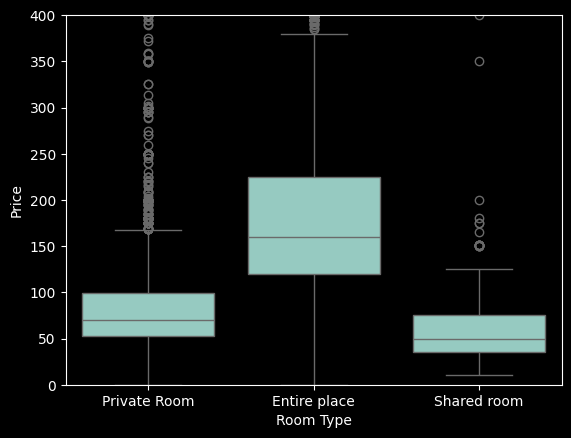

In [ ]:
# Visualize relationship between price and room_type
sns.boxplot(x = 'room_type', y = 'price', data = airbnb)
plt.ylim(0, 400)
plt.xlabel('Room Type')
plt.ylabel('Price')
plt.show()

In [ ]:
# Get median price per room_type
airbnb.groupby('room_type')['price'].median()

room_type
Entire place    160.0
Private Room     70.0
Shared room      50.0
Name: price, dtype: float64

In [ ]:
# Impute price based on conditions
airbnb.loc[(airbnb['price'].isna()) & (airbnb['room_type'] == 'Entire place'), 'price'] = 163.0
airbnb.loc[(airbnb['price'].isna()) & (airbnb['room_type'] == 'Private Room'), 'price'] = 70.0
airbnb.loc[(airbnb['price'].isna()) & (airbnb['room_type'] == 'Shared Room'), 'price'] = 50.0

In [ ]:
# Confirm price has been imputed
airbnb.isna().sum()

listing_id               0
name                     5
host_id                  0
host_name                2
neighbourhood_full       0
coordinates              0
room_type                0
price                    0
number_of_reviews        0
last_review           2075
reviews_per_month        0
availability_365         0
rating                2075
number_of_stays          0
5_stars                  0
listing_added            0
is_rated                 0
dtype: int64

### What's still to be done?

Albeit we've done a significant amount of data cleaning tasks, there are still a couple of problems we have yet to diagnose. When cleaning data, we need to consider:

- Values that do not make any sense *(for example: are there values of `last_review` that older than `listing_added`? Are there listings in the future?*)
- Presence of duplicates values - and how to deal with them?

##### **Task 8:** Do we have consistent date data?

In [15]:
# Doing some sanity checks on date data
today = dt.date.today()

In [16]:
# Are there reviews in the future?
airbnb['last_review'] = pd.to_datetime(airbnb['last_review'])
airbnb[airbnb['last_review'].dt.date > today]

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude


In [17]:
# Are there listings in the future?
airbnb['listing_added'] = pd.to_datetime(airbnb['listing_added'])
airbnb[airbnb['listing_added'].dt.date > today]

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude


In [18]:
# Drop these rows since they are only 4 rows
airbnb = airbnb[~(airbnb['listing_added'].dt.date > today)]

In [19]:
# Are there any listings with listing_added > last_review
inconsistent_dates = airbnb[airbnb['listing_added'].dt.date > airbnb['last_review'].dt.date]
inconsistent_dates

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side","40.71884,-73.98354",Private room,160$,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23,40.71884,-73.98354
50,20783900,Marvelous Manhattan Marble Hill Private Suites,148960265,Randy,"Manhattan, Marble Hill","40.87618,-73.91266",Private room,93$,7,2018-10-06,0.32,0,4.868036,8.4,0.609263,2020-02-17,40.87618,-73.91266
60,1908852,Oversized Studio By Columbus Circle,684629,Alana,"Manhattan, Upper West Side","40.7706,-73.98919000000002",Entire home/apt,189$,7,2016-05-06,0.13,0,4.841204,8.4,0.725995,2017-09-17,40.77060,-73.98919
124,28659894,Private bedroom in prime Bushwick! Near Trains!!!,216235179,Nina,"Brooklyn, Bushwick","40.69988,-73.92071999999997",Private room,55$,4,2019-04-12,0.58,358,4.916252,4.8,0.703117,2020-08-23,40.69988,-73.92072
511,33619855,Modern & Spacious in trendy Crown Heights,253354074,Yehudis,"Brooklyn, Crown Heights","40.66387,-73.9384",home,150$,6,2019-05-27,2.50,148,3.462432,7.2,0.610929,2020-10-07,40.66387,-73.93840
521,25317793,Awesome Cozy Room in The Heart of Sunnyside!,136406167,Kara,"Queens, Sunnyside","40.7409,-73.92696",Private room,65$,22,2019-06-11,1.63,131,4.442485,26.4,0.722388,2020-10-22,40.74090,-73.92696


In [20]:
# Drop these rows since they are only 2 rows
airbnb.drop(inconsistent_dates.index, inplace = True)

##### **Task 9:** Let's deal with duplicate data


There are two notable types of duplicate data:

- Identical duplicate data across all columns
- Identical duplicate data cross most or some columns

To diagnose, and deal with duplicate data, we will be using the following methods and functions:

- `.duplicated(subset = , keep = )`
  - `subset` lets us pick one or more columns with duplicate values.
  - `keep` returns lets us return all instances of duplicate values.
- `.drop_duplicates(subset = , keep = )`
  

In [21]:
# Print the header of the DataFrame again
airbnb.head()

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands","40.63222,-73.93398",Private room,45$,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08,40.63222,-73.93398
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side","40.78761,-73.96862",Entire home/apt,135$,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25,40.78761,-73.96862
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights","40.7007,-73.99517",Entire home/apt,150$,0,NaT,NaN,65,NaN,NaN,NaN,2018-08-15,40.70070,-73.99517
3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side","40.79169,-73.97498",Entire home/apt,86$,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20,40.79169,-73.97498
5,271954,Beautiful brownstone apartment,1423798,Aj,"Manhattan, Greenwich Village","40.73388,-73.99452",Entire home/apt,150$,203,2019-06-20,2.22,300,4.478396,243.6,0.743500,2018-12-15,40.73388,-73.99452


In [22]:
# Find duplicates
duplicates = airbnb.duplicated()
print(f"Number of identical duplicates: {duplicates.sum()}")

Number of identical duplicates: 13


In [23]:
# Remove identical duplicates
irbnb = airbnb.drop_duplicates()

In [24]:
# Find non-identical duplicates
non_identical_duplicates = airbnb.duplicated(subset=['listing_id'], keep=False)

In [25]:
# Show all duplicates
airbnb[non_identical_duplicates].sort_values(by='listing_id')

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude
1145,253806,Loft Suite @ The Box House Hotel,417504,The Box House Hotel,"Brooklyn, Greenpoint","40.73652,-73.95236",Entire home/apt,199$,43,2019-07-02,0.47,60,4.620238,51.6,0.861086,2018-12-27,40.73652,-73.95236
6562,253806,Loft Suite @ The Box House Hotel,417504,The Box House Hotel,"Brooklyn, Greenpoint","40.73652,-73.95236",Entire home/apt,199$,43,2019-07-02,0.47,60,4.620238,51.6,0.861086,2018-12-27,40.73652,-73.95236
8699,2044392,The heart of Williamsburg 2 bedroom,620218,Sarah,"Brooklyn, Williamsburg","40.71257,-73.96149",Entire home/apt,245$,0,NaT,NaN,0,NaN,NaN,NaN,2018-08-09,40.71257,-73.96149
5761,2044392,The heart of Williamsburg 2 bedroom,620218,Sarah,"Brooklyn, Williamsburg","40.71257,-73.96149",Entire home/apt,250$,0,NaT,NaN,0,NaN,NaN,NaN,2018-05-24,40.71257,-73.96149
4187,4244242,Best Bedroom in Bedstuy/Bushwick. Ensuite bath...,22023014,BrooklynSleeps,"Brooklyn, Bedford-Stuyvesant","40.69496,-73.93949",Private room,73$,110,2019-06-23,1.96,323,4.962314,132.0,0.809882,2018-12-18,40.69496,-73.93949
2871,4244242,Best Bedroom in Bedstuy/Bushwick. Ensuite bath...,22023014,BrooklynSleeps,"Brooklyn, Bedford-Stuyvesant","40.69496,-73.93949",Private room,70$,110,2019-06-23,1.96,323,4.962314,132.0,0.809882,2018-12-18,40.69496,-73.93949
77,7319856,450ft Square Studio in Gramercy NY,11773680,Adam,"Manhattan, Kips Bay","40.73813,-73.98098",Entire home/apt,289$,4,2016-05-22,0.09,225,3.903764,4.8,0.756381,2015-11-17,40.73813,-73.98098
2255,7319856,450ft Square Studio in Gramercy NY,11773680,Adam,"Manhattan, Kips Bay","40.73813,-73.98098",Entire home/apt,280$,4,2016-05-22,0.09,225,3.903764,4.8,0.756381,2015-11-17,40.73813,-73.98098
555,9078222,"Prospect Park 3 bdrm, Sleeps 8 (#2)",47219962,Babajide,"Brooklyn, Prospect-Lefferts Gardens","40.66086,-73.96159",Entire home/apt,154$,123,2019-07-01,2.74,263,3.466881,147.6,0.738191,2018-12-26,40.66086,-73.96159
7933,9078222,"Prospect Park 3 bdrm, Sleeps 8 (#2)",47219962,Babajide,"Brooklyn, Prospect-Lefferts Gardens","40.66086,-73.96159",Entire home/apt,150$,123,2019-07-01,2.74,263,3.466881,147.6,0.738191,2018-12-26,40.66086,-73.96159


To treat identical duplicates across some columns, we will chain the `.groupby()` and `.agg()` methods where we group by the column used to find duplicates (`listing_id`) and aggregate across statistical measures for `price`, `rating` and `list_added`. The `.agg()` method takes in a dictionary with each column's aggregation method - we will use the following aggregations:

- `mean` for `price` and `rating` columns
- `max` for `listing_added` column
- `first` for all remaining column

*A note on dictionary comprehensions:*

Dictionaries are useful data structures in Python with the following format
`my_dictionary = {key: value}` where a `key` is mapped to a `value` and whose `value` can be returned with `my_dictionary[key]` - dictionary comprehensions allow us to programmatically create dicitonaries using the structure:

```
{x: x*2 for x in [1,2,3,4,5]}
{1:2, 2:4, 3:6, 4:8, 5:10}
```

In [ ]:
airbnb['logprice'] = np.log(airbnb['price'])
sns.histplot(airbnb['logprice'], kde=True, bins=20)
plt.grid()
plt.show()

In [ ]:
airbnb['price_cat'] = pd.cut(airbnb['logprice'], [0, 100, 200, 300, 400, 500, 600, 1000, 2000, 5000, 8000])
airbnb['price_cat'].unique
